# Model Predictions

This notebooks purpose is to compare the predicted states to the actual states infeered from the open window

In [1]:
import matplotlib.pyplot as plt
from src.utils import load_model
from src.data import load_and_aggregate_data
import jax.numpy as jnp
import numpy as np
import os 
from dotenv import load_dotenv

In [2]:
df = load_and_aggregate_data()
ys = jnp.array(df["CO2C"].values)
window_indicator = jnp.array(df["WindowClosed"].values)
df

,HalfHour1,CO2C,WindowClosed,Time,Day,Month,Hour,HalfHour
0,24,501.640625,0.5,0.020833,18.0,3.0,11.500000,24
1,25,636.562500,1.0,0.041667,18.0,3.0,12.000000,25
2,26,636.562500,1.0,0.062500,18.0,3.0,12.666667,26
3,27,626.875000,1.0,0.083333,18.0,3.0,13.000000,27
4,28,536.145833,1.0,0.104167,18.0,3.0,13.666667,28
...,...,...,...,...,...,...,...,...
1661,1685,1299.583333,1.0,34.625000,22.0,4.0,2.000000,5
1662,1686,1300.000000,1.0,34.645833,22.0,4.0,2.666667,6
1663,1687,1118.645833,1.0,34.666667,22.0,4.0,3.000000,7
1664,1688,1269.270833,1.0,34.687500,22.0,4.0,3.666667,8


In [152]:
BASE_MODEL_PATH = os.getenv("MODEL_PATH") + "/"
BASE_MODEL_PATH

'/Users/madshaakonsson/Desktop/7-semester/hmm-modelling/results/models/'

In [160]:
#Finding first 00 in data 
time = df["Time"].values
start_idx = np.where(time == 1)[0][0]
hour = df["Hour"].values
start_idx = np.where(hour == 0)[0][0]
print(f"First 00 in data at index: {start_idx}, time: {time[start_idx]}={time[start_idx]*24}, hour: {hour[start_idx]}")

First 00 in data at index: 24, time: 0.5208333333333334=12.5, hour: 0.0


In [3]:
#Finding first 00 in data 
time = df["Time"].values
start_idx = np.where(time == 1)[0][0]
hour = df["Hour"].values
start_idx = np.where(hour == 0)[0][0]
print(f"First 00 in data at index: {start_idx}, time: {time[start_idx]}={time[start_idx]*24}, hour: {hour[start_idx]}")

First 00 in data at index: 25, time: 0.5416666666666666=13.0, hour: 0.0


In [4]:
hour

array([11.5       , 12.        , 12.66666667, ...,  3.        ,
        3.66666667,  4.        ], shape=(1666,))

### Checking First Model

In [154]:
def plot_predictions(model, ys, window_indicator, start_time=0, timesteps=48, state=0):
    """
    Plots the first 24 hours of predictions from the model against the actual data.
    """
    # Get the first 24 hours of data

    y_true = ys[start_time:start_time + timesteps] #Co2 levels indicating occupant presence
    ws = window_indicator[start_time:start_time + timesteps] #Avg. of the open anc closed window indicator per 30 min interval
    state_results = model.state_results #State results from the model
    ut = jnp.asarray(state_results.ut).T #Inferrred states for the current time step 
    utt = jnp.asarray(state_results.utt).T #predicted states for the current time step
    ut = ut[state, start_time:start_time + timesteps] #Inferrred states for the current time step
    utt = utt[state, start_time:start_time + timesteps] #predicted states for the current time step 


    timesteps = range(timesteps) 
    plt.figure(figsize=(12, 6))
    plt.plot(timesteps, y_true, label='True CO2 Levels', color='blue') #Plot on a secondary y-axis
    plt.legend()
    plt.twinx()
    plt.plot(timesteps, ws, label='Window Indicator', color='orange')
    plt.plot(timesteps, ut, label='Predicted States (ut)', color='green')
    plt.plot(timesteps, utt, label='Inffered States (utt)', color='red')
    plt.xlabel('Time Steps (30 min intervals)')
    plt.ylabel('Values')
    plt.title('Model Predictions vs True CO2 Levels')
    plt.legend()
    plt.grid()
    plt.show()


def plot_predictions_all_states(model, ys, window_indicator, start_time=0, timesteps=48):
    """
    Plots the predictions from the model against the actual data, split across 4 subplots (one for each state).
    """
    # Get the data for the specified time window
    y_true = ys[start_time:start_time + timesteps] 
    ws = window_indicator[start_time:start_time + timesteps] 
    state_results = model.state_results 
    ut = jnp.asarray(state_results.ut).T 
    utt = jnp.asarray(state_results.utt).T 

    time_axis = range(timesteps) 
    
    # Create a 4x1 grid of subplots, sharing the x-axis
    fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 16), sharex=True)
    
    # Ensure axes is iterable even if someone changes nrows to 1 in the future
    if not isinstance(axes, np.ndarray):
        axes = [axes]
        
    for state, ax in enumerate(axes):
        # Safety check: break if there are fewer states than subplots
        if state >= ut.shape[0]: 
            break 
            
        # 1. Plot True CO2 on the primary y-axis
        ax.plot(time_axis, y_true, label='True CO2 Levels', color='blue', linewidth=2)
        ax.set_ylabel('CO2 Levels', color='blue')
        ax.tick_params(axis='y', labelcolor='blue')
        ax.grid(True, alpha=0.3)
        
        # 2. Create a secondary y-axis for the indicator and states
        ax2 = ax.twinx()
        
        # 3. Plot the window indicator and state arrays on the secondary axis
        ut_slice = ut[state, start_time:start_time + timesteps]
        utt_slice = utt[state, start_time:start_time + timesteps]
        
        ax2.plot(time_axis, ws, label='Window Indicator', color='orange', alpha=0.5)
        ax2.plot(time_axis, ut_slice, label=f'Predicted (ut)', color='green', linestyle='--')
        ax2.plot(time_axis, utt_slice, label=f'Inferred (utt)', color='red', linestyle=':')
        
        ax2.set_ylabel(f'State {state} Probs / Indicator')
        
        # 4. Combine legends for both axes so they don't overlap
        lines_1, labels_1 = ax.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=9)
        
        ax.set_title(f'State {state} Predictions vs Actuals')

    plt.xlabel('Time Steps (30 min intervals)')
    
    # Use tight_layout to prevent subplot titles and labels from overlapping
    plt.tight_layout()
    plt.show()



In [155]:
MODEL = "ar_hmm.pkl"
model = load_model(BASE_MODEL_PATH + MODEL)

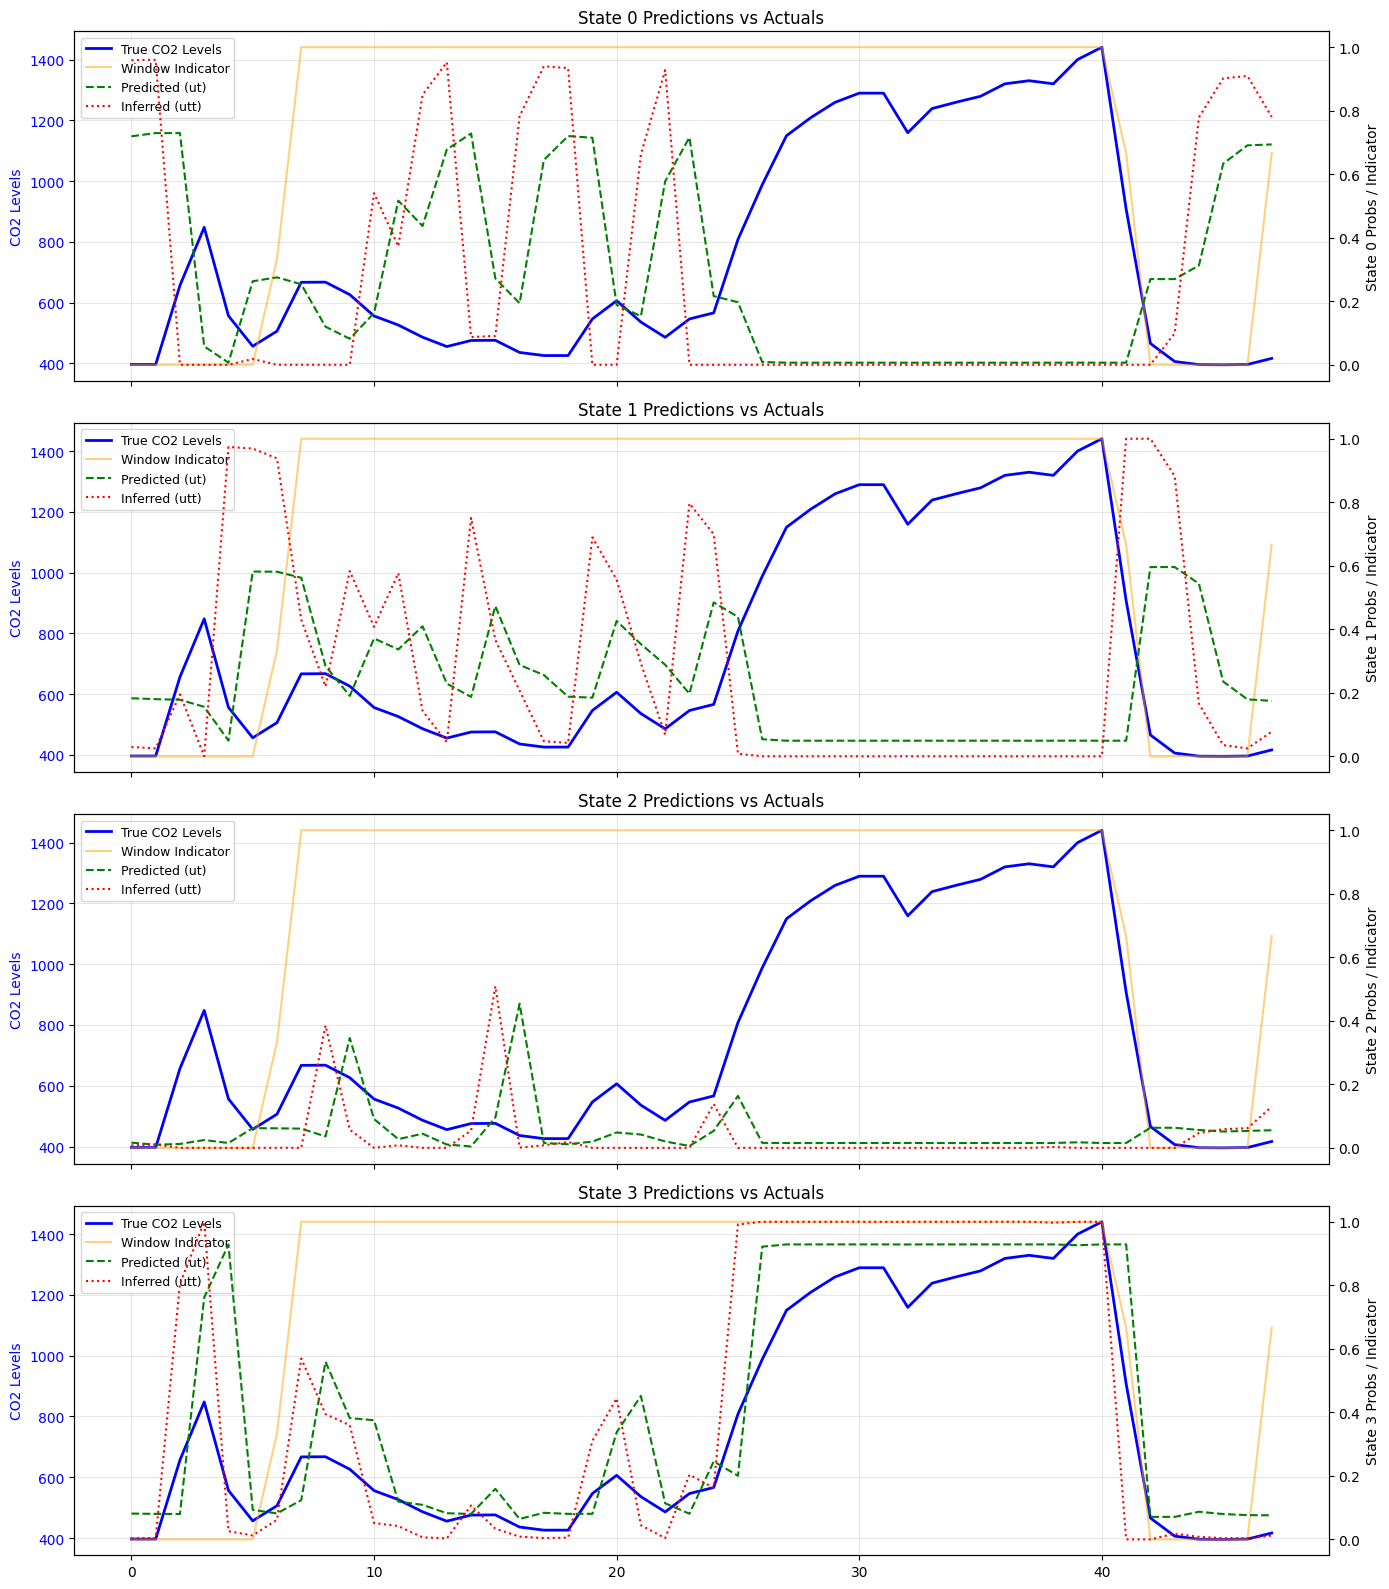

In [156]:
plot_predictions_all_states(model, ys, window_indicator, start_time=50, timesteps=48)

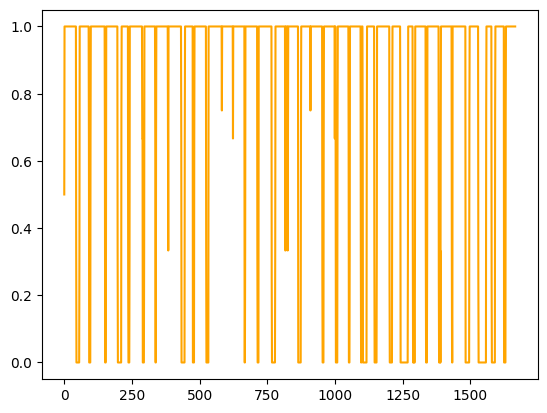

In [157]:
plt.plot(window_indicator, label='Window Indicator', color='orange')

Model: ordinary_hmm.pkl


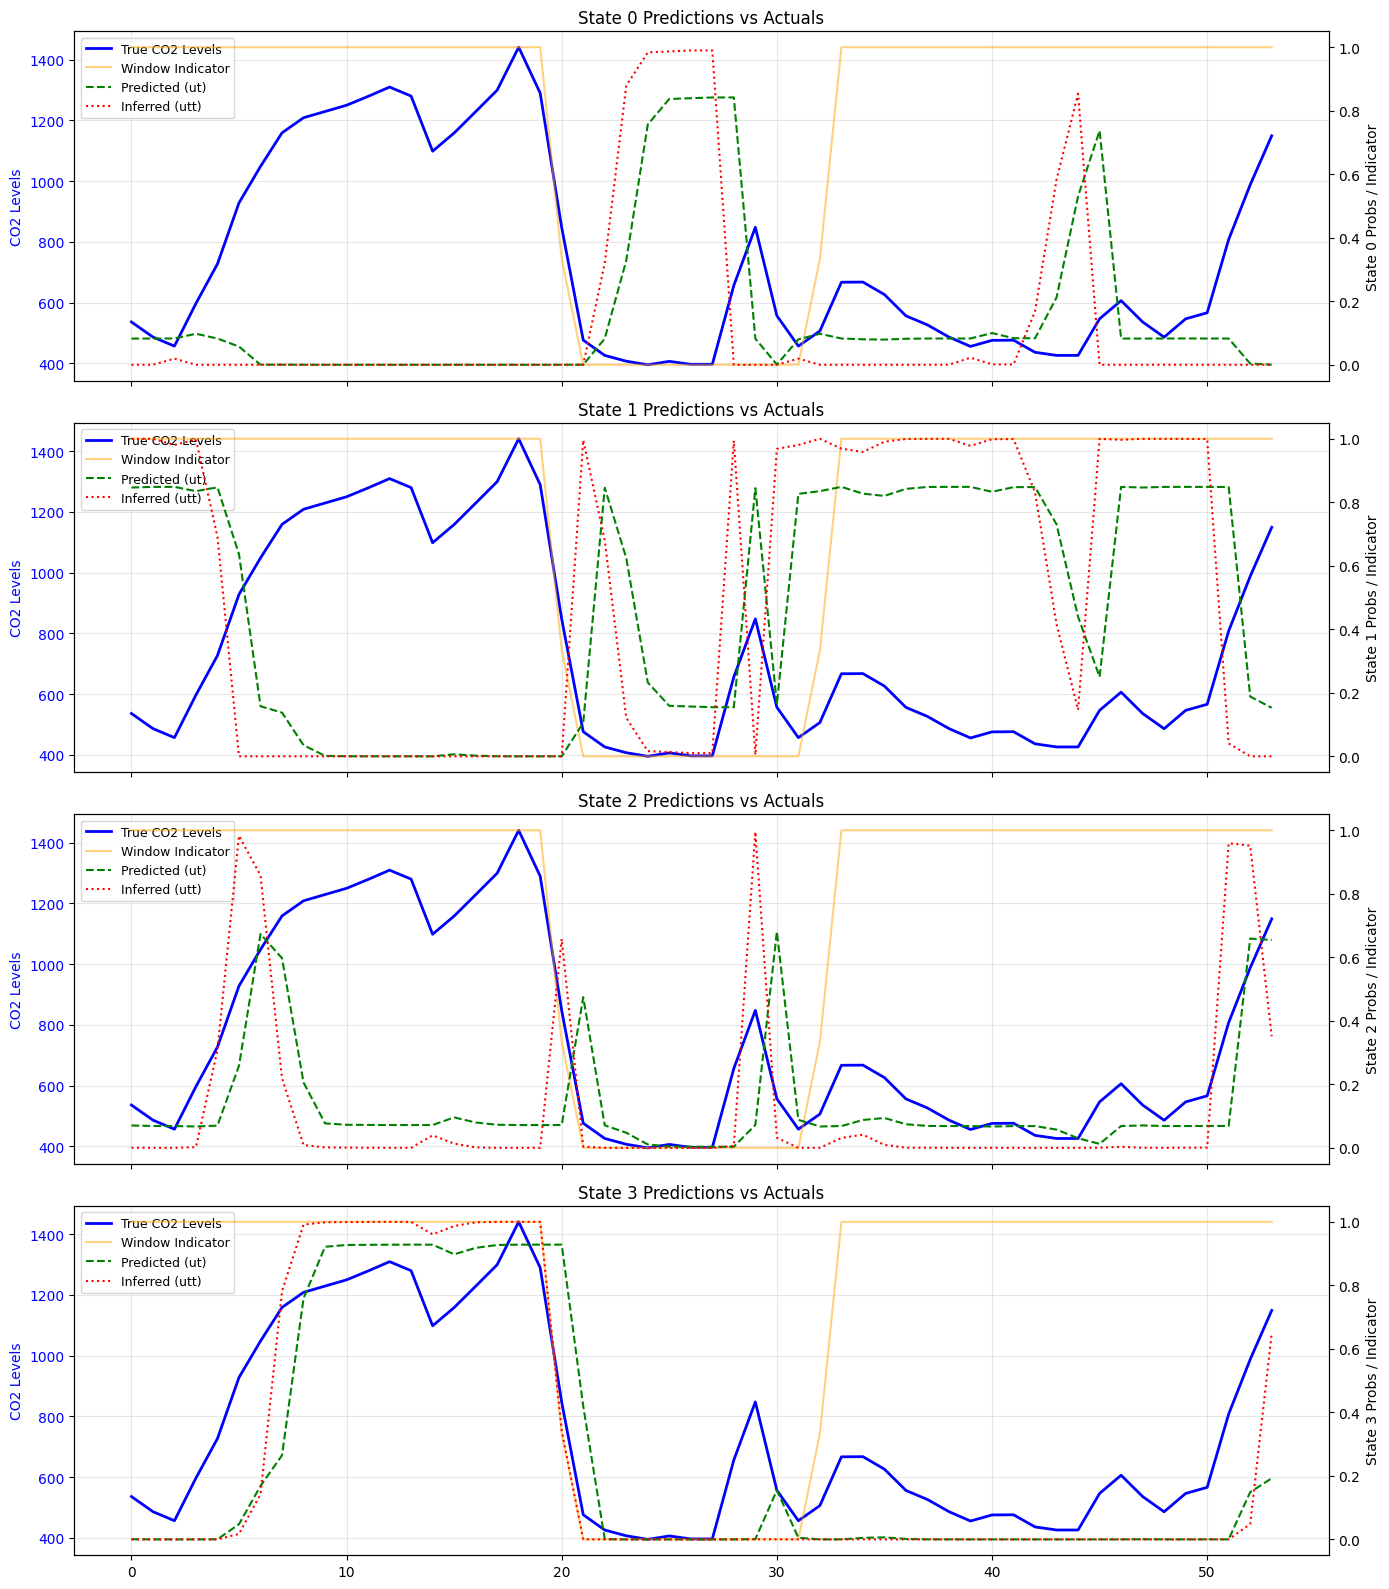

Model: ar_hmm.pkl


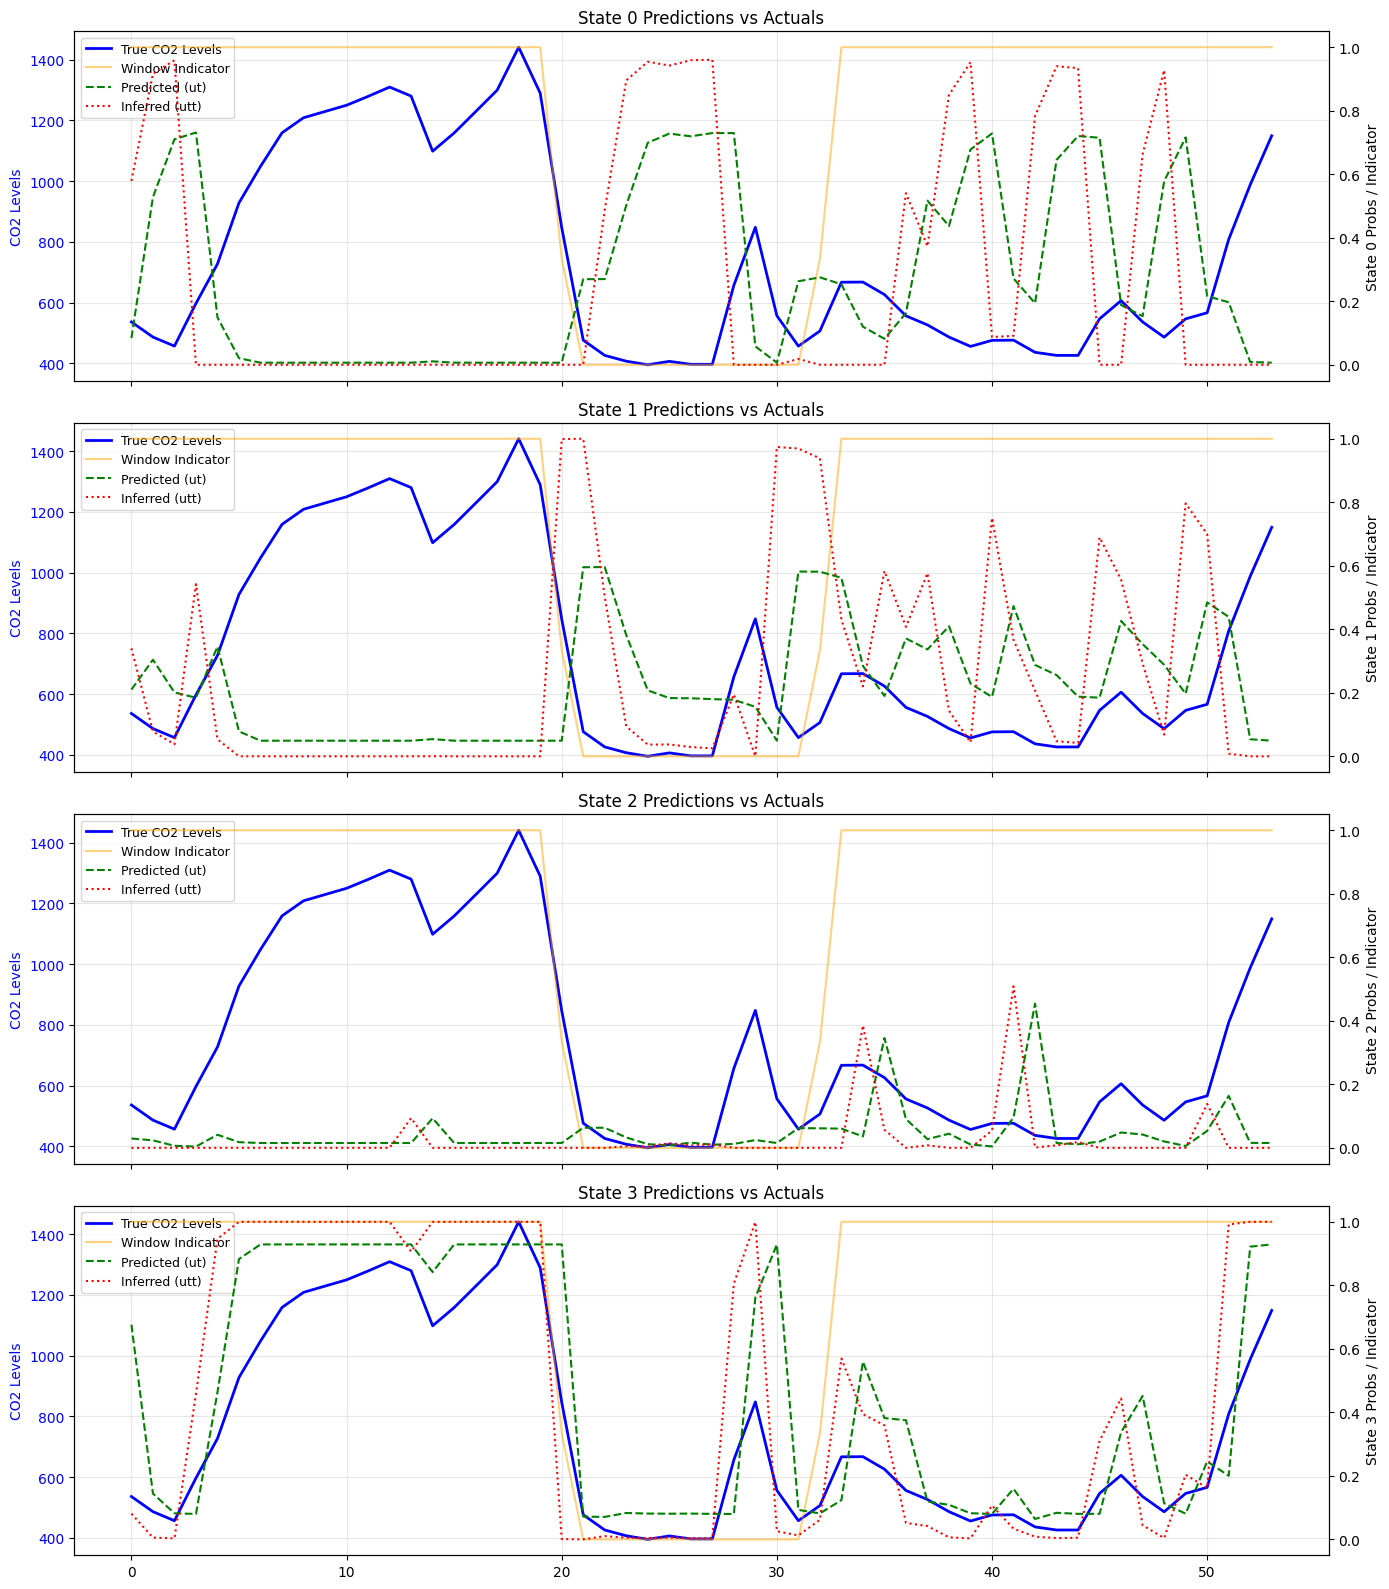

Model: ar_2_hmm.pkl


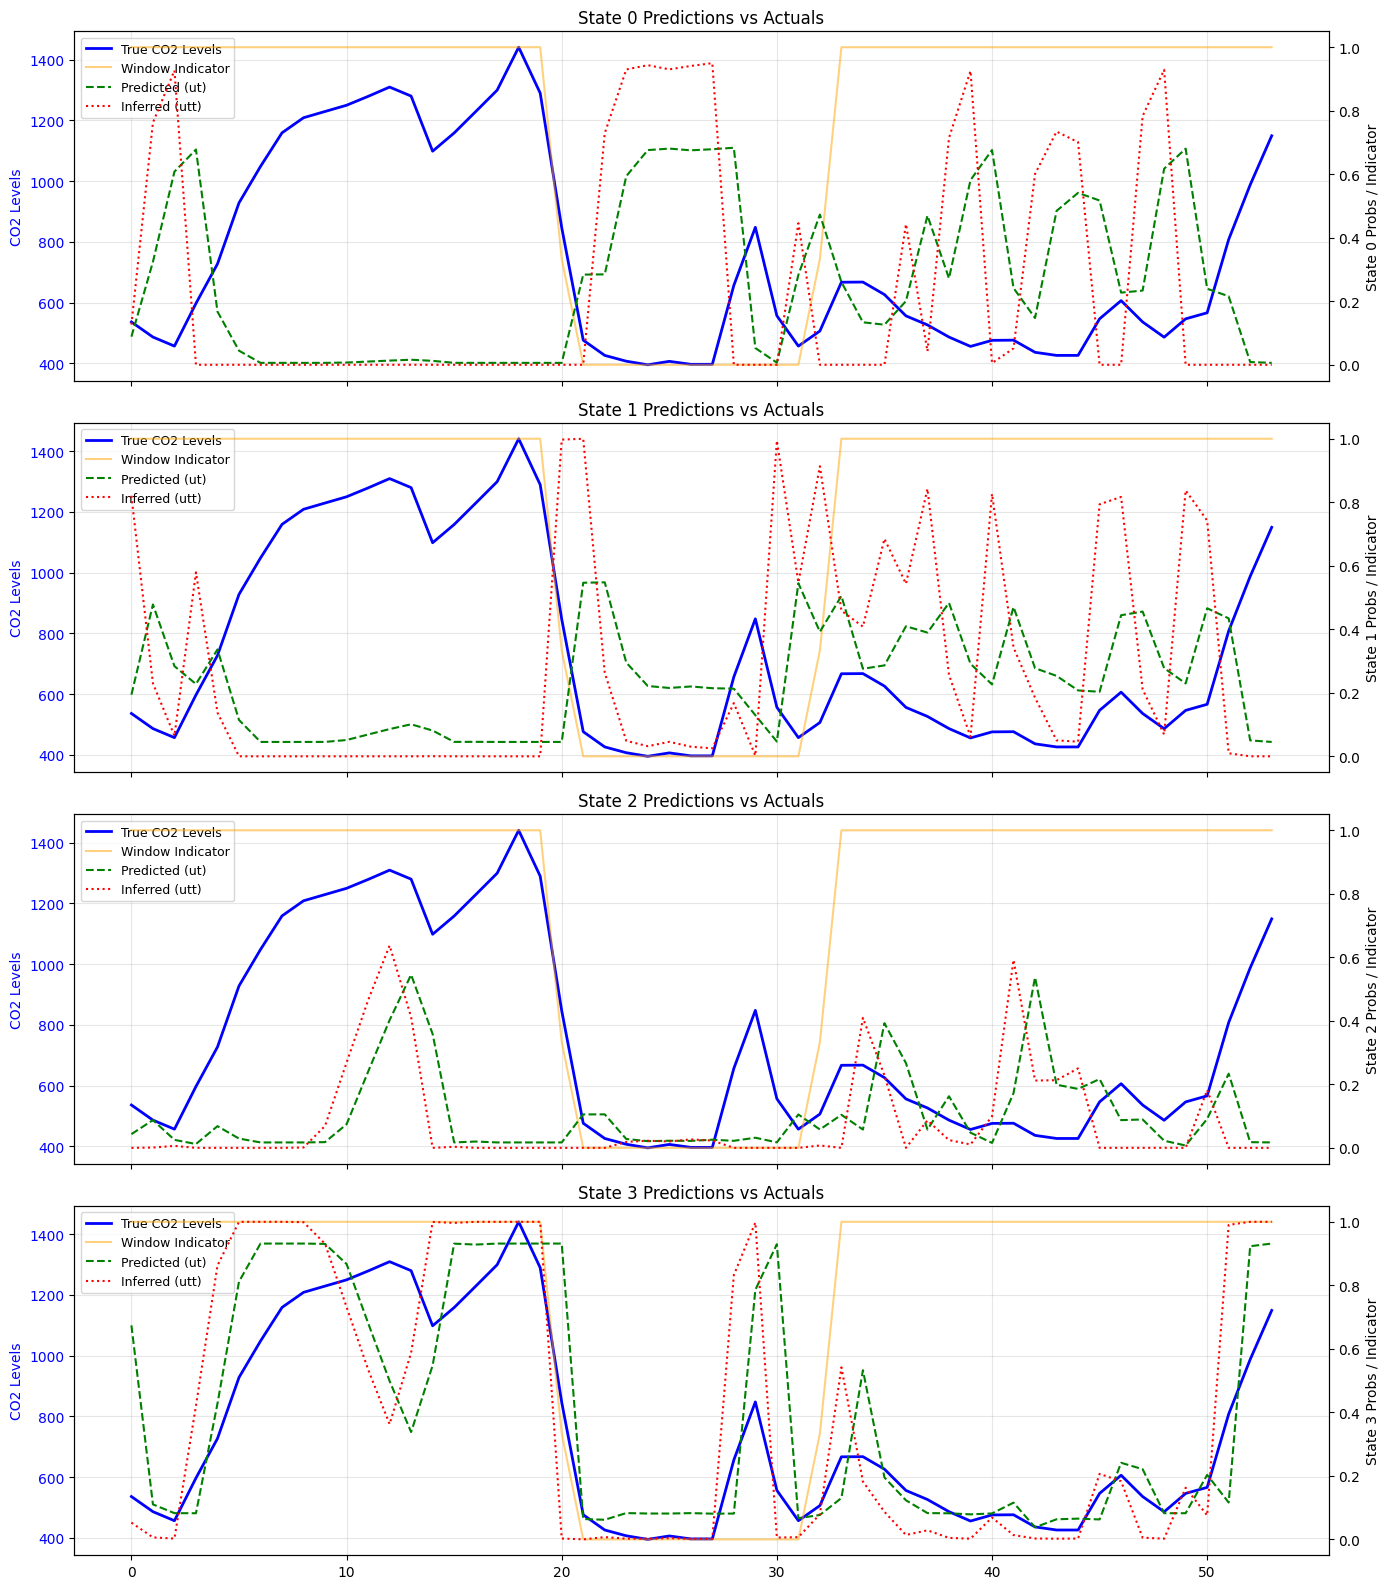

Model: second_order_hmm.pkl


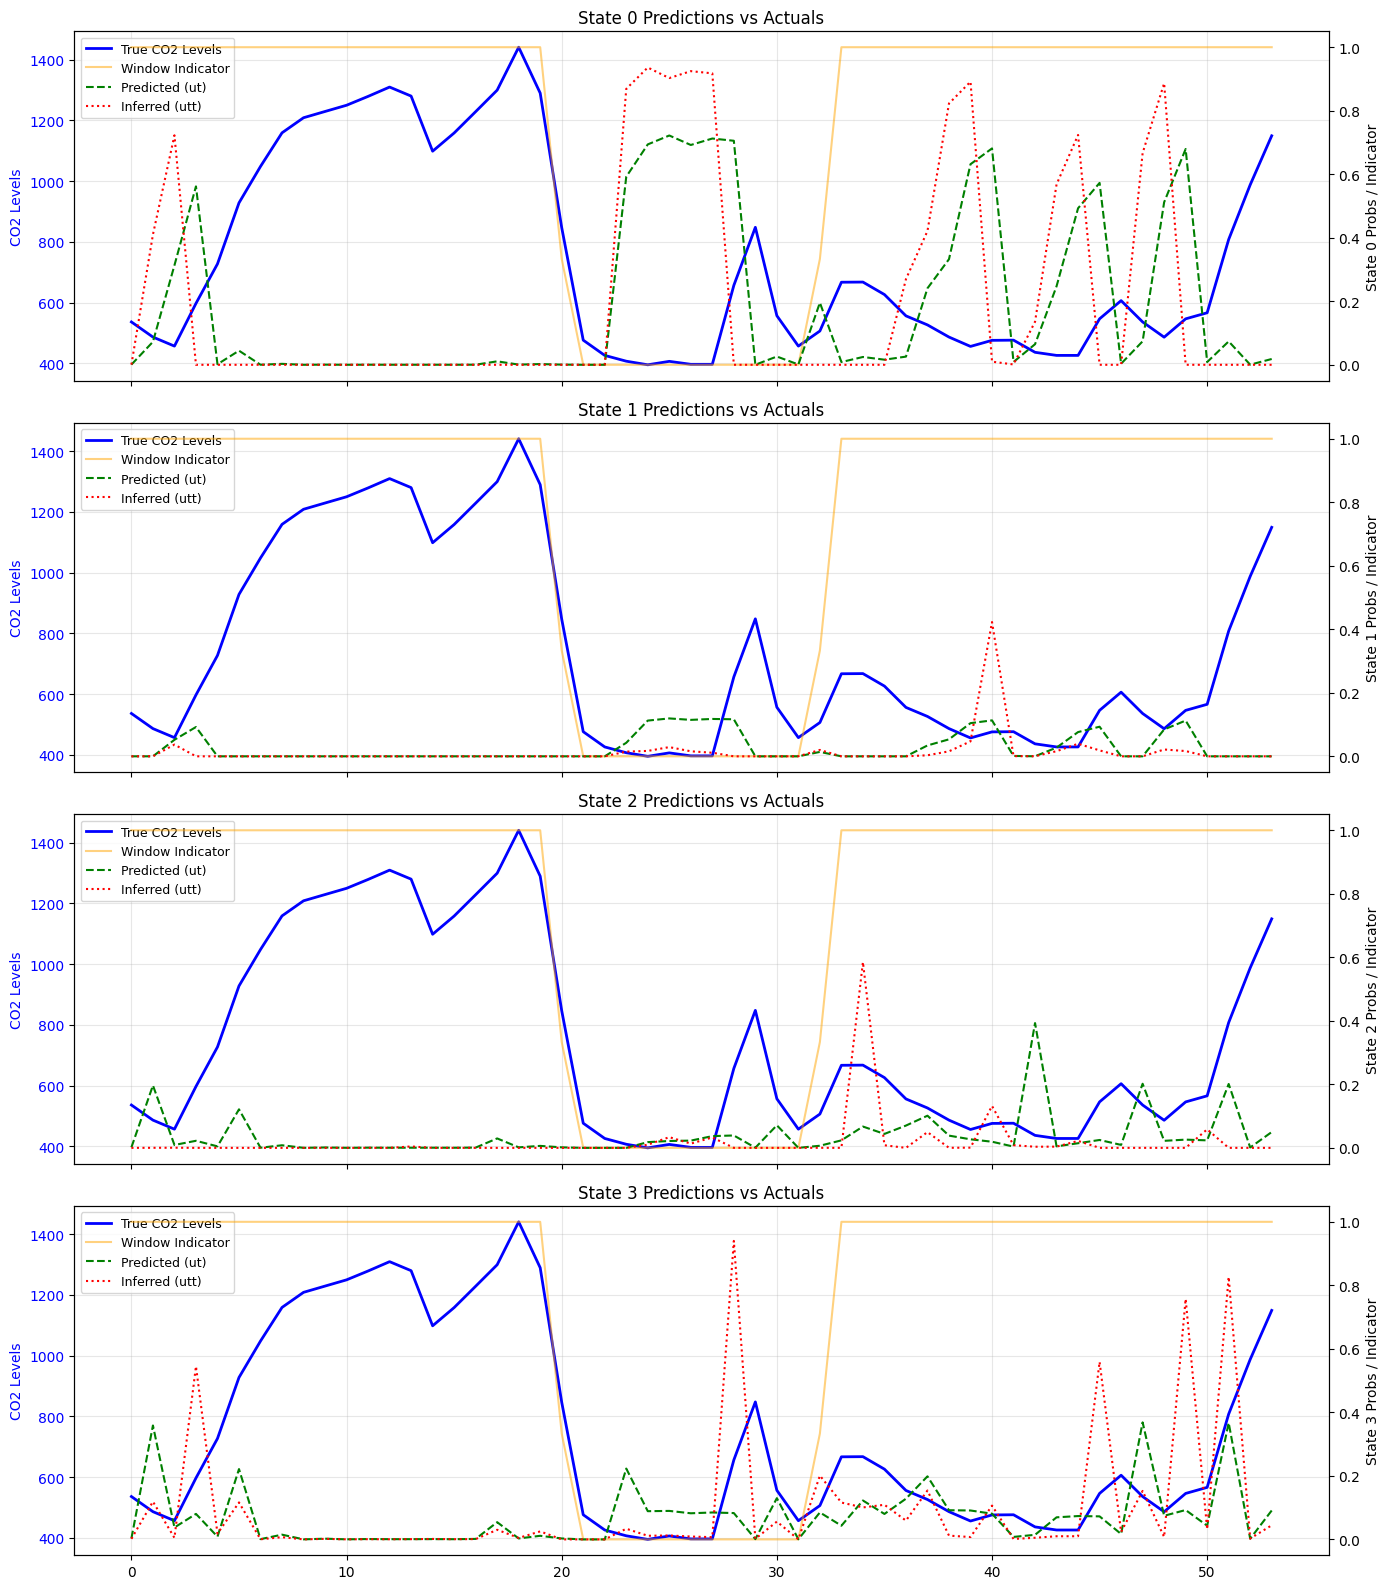

Model: covariate_hmm.pkl


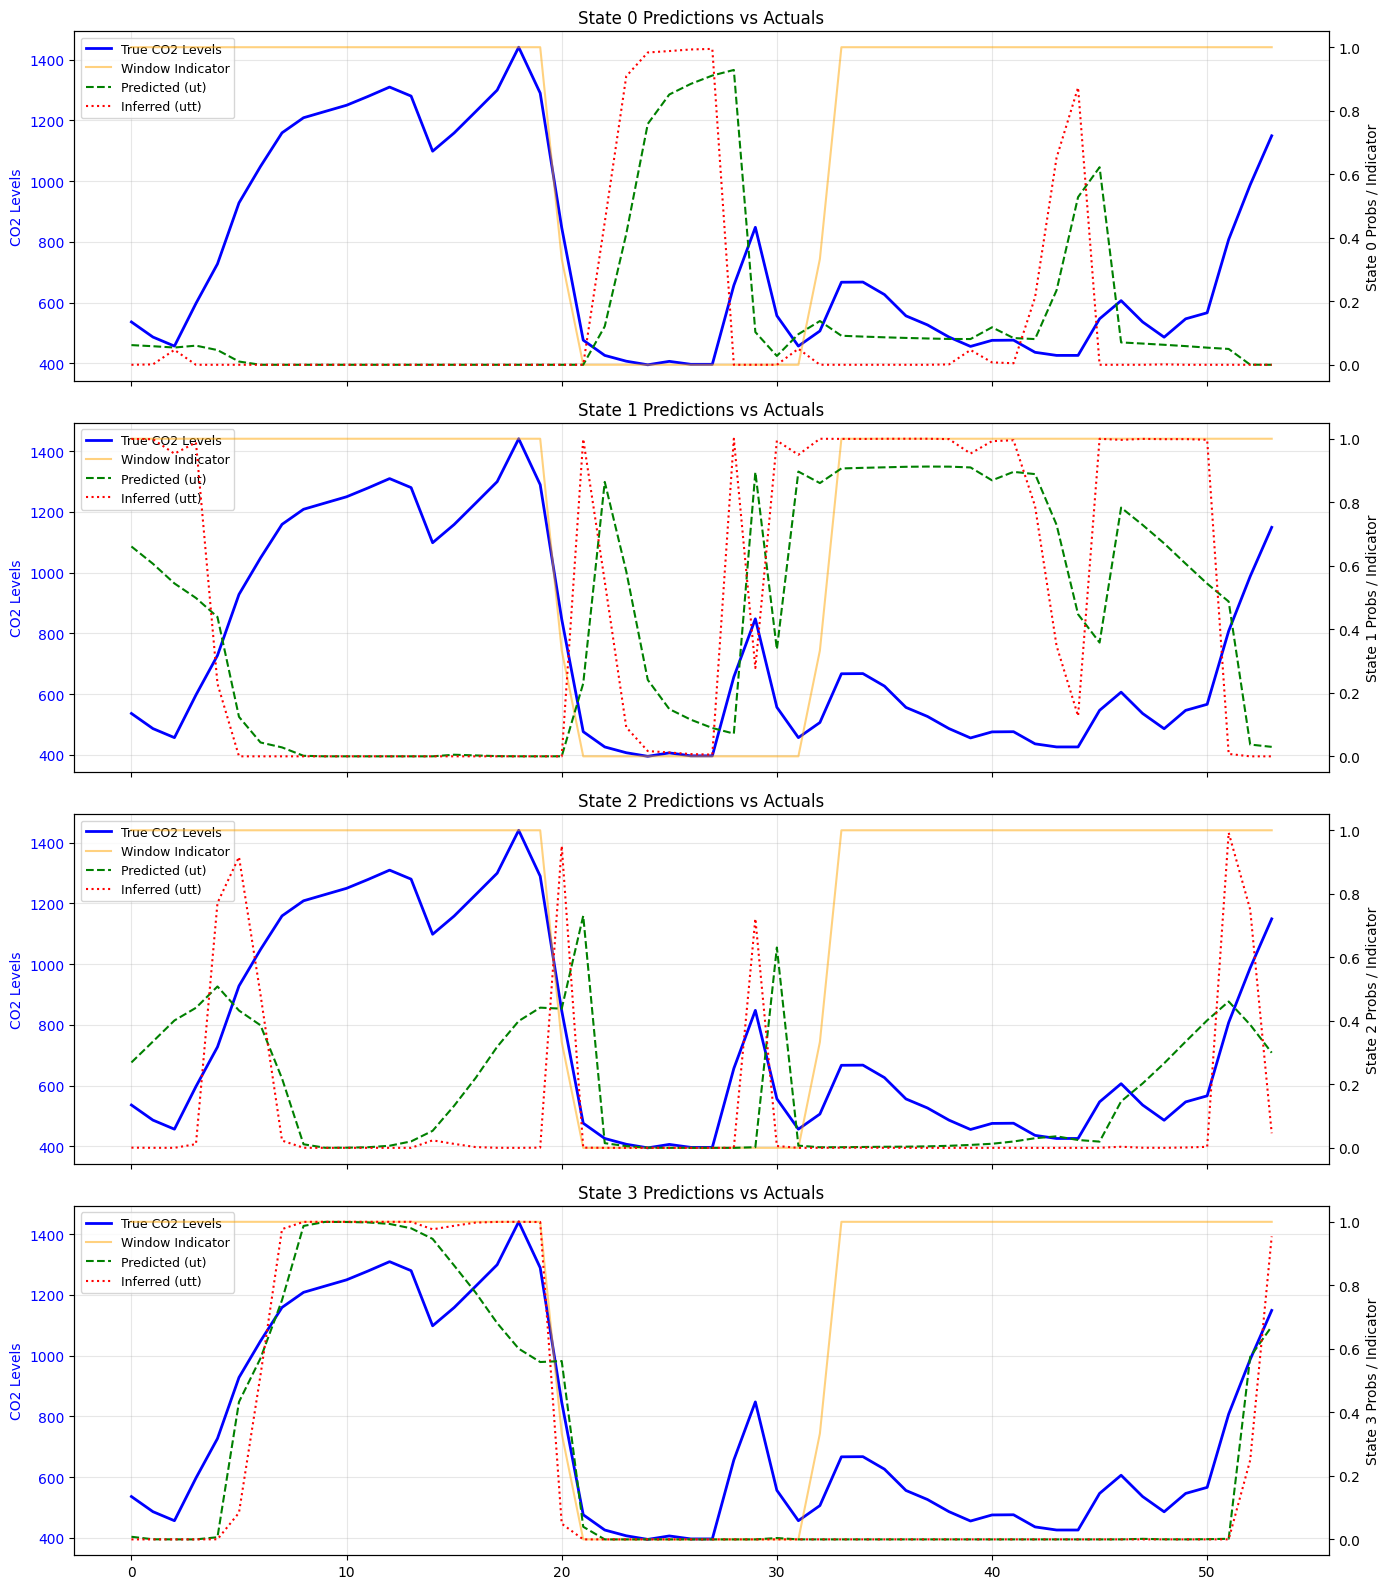

Model: ar_1_covariate_hmm.pkl


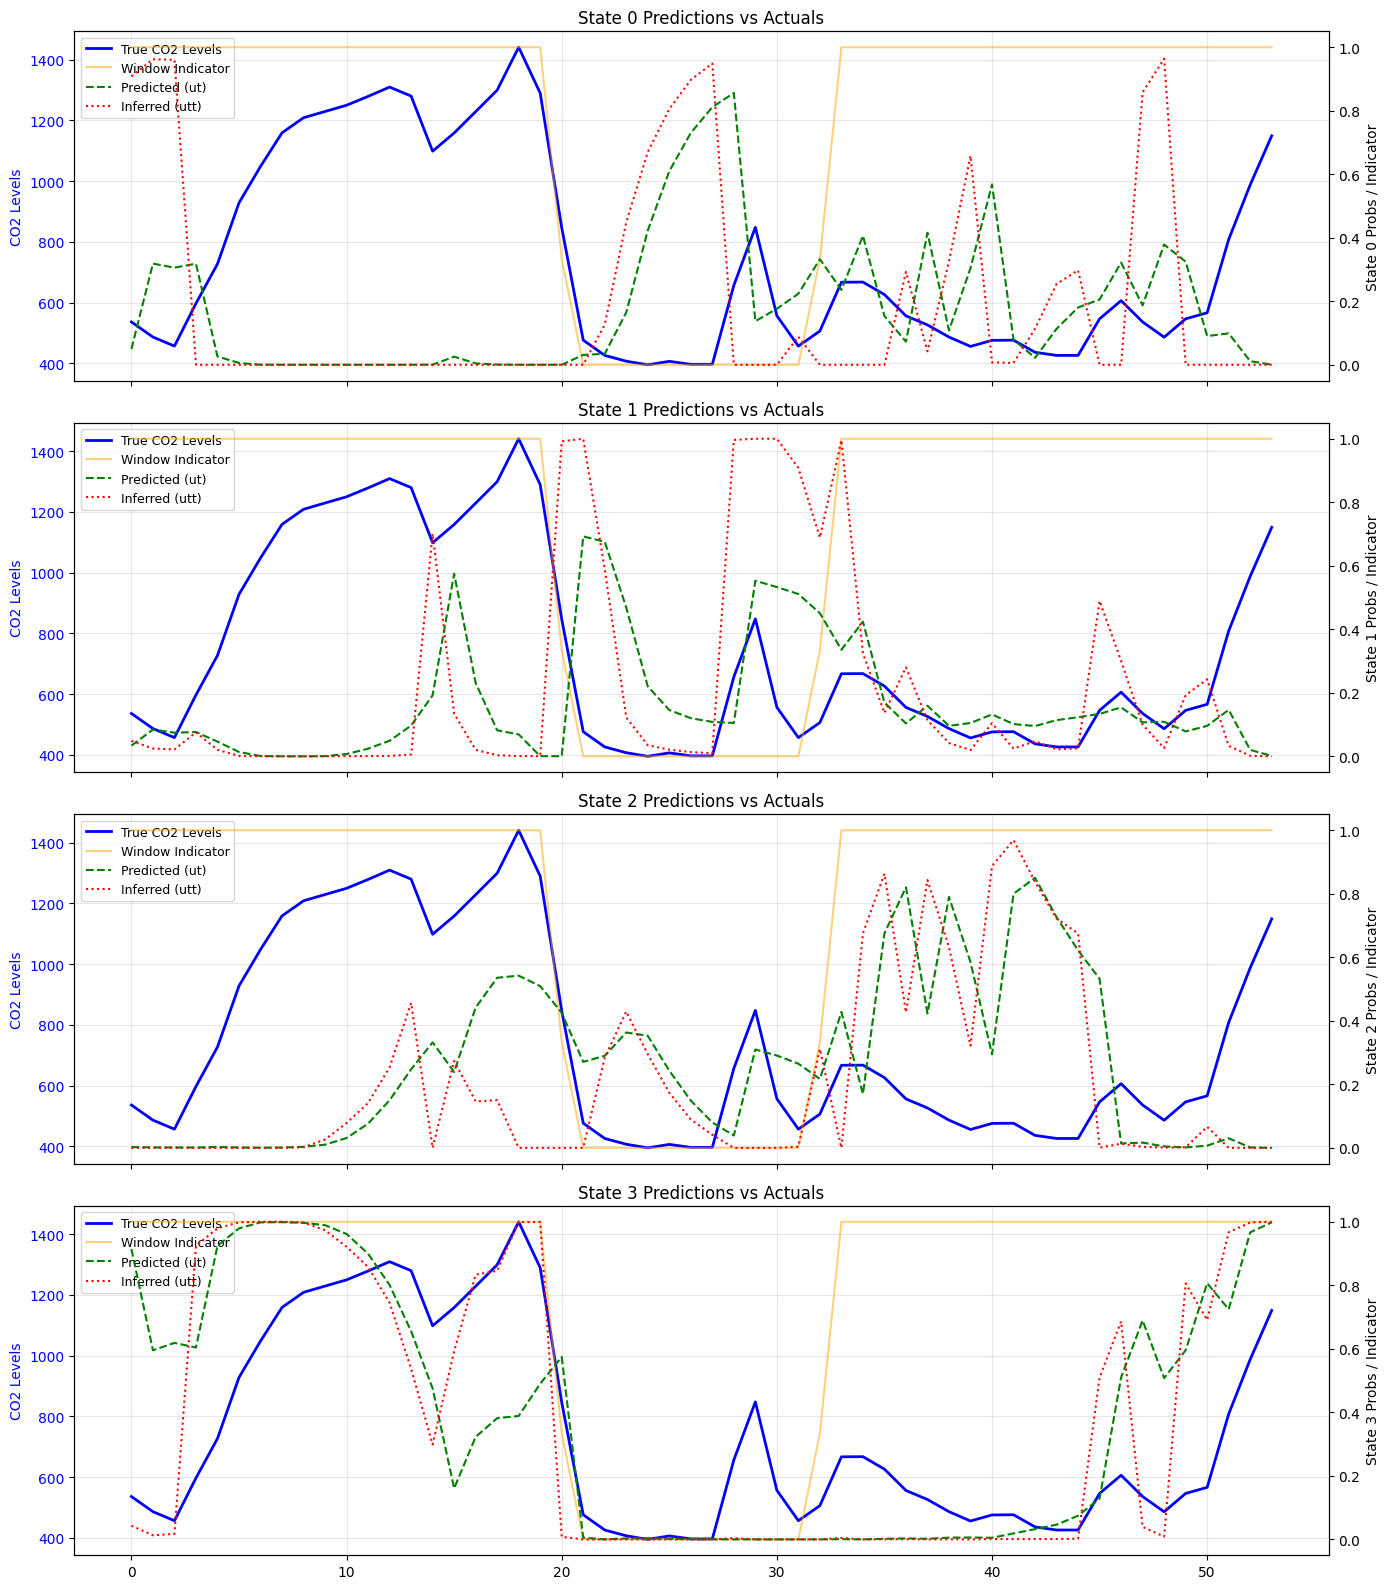

Model: ar_2_covariate_hmm.pkl


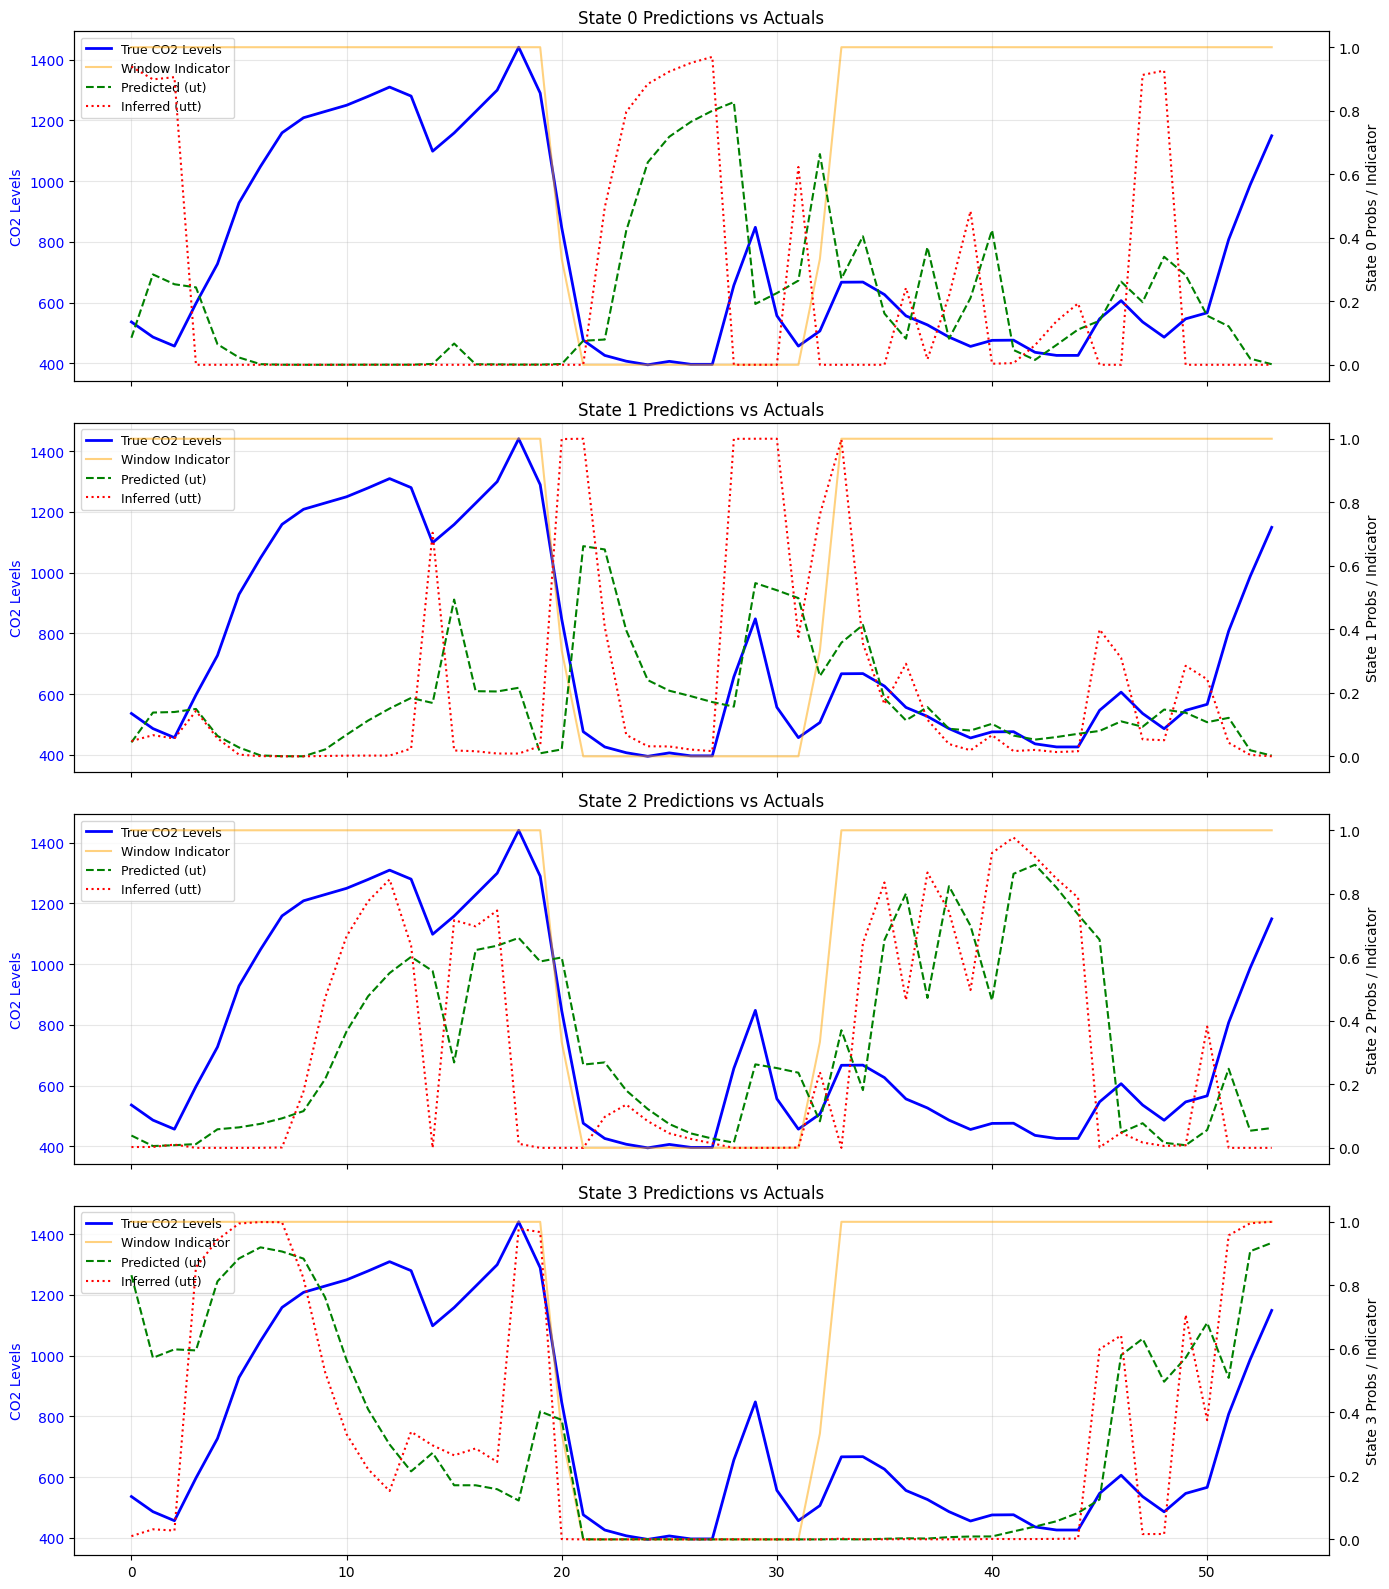

Model: ar_2_second_order_hmm.pkl


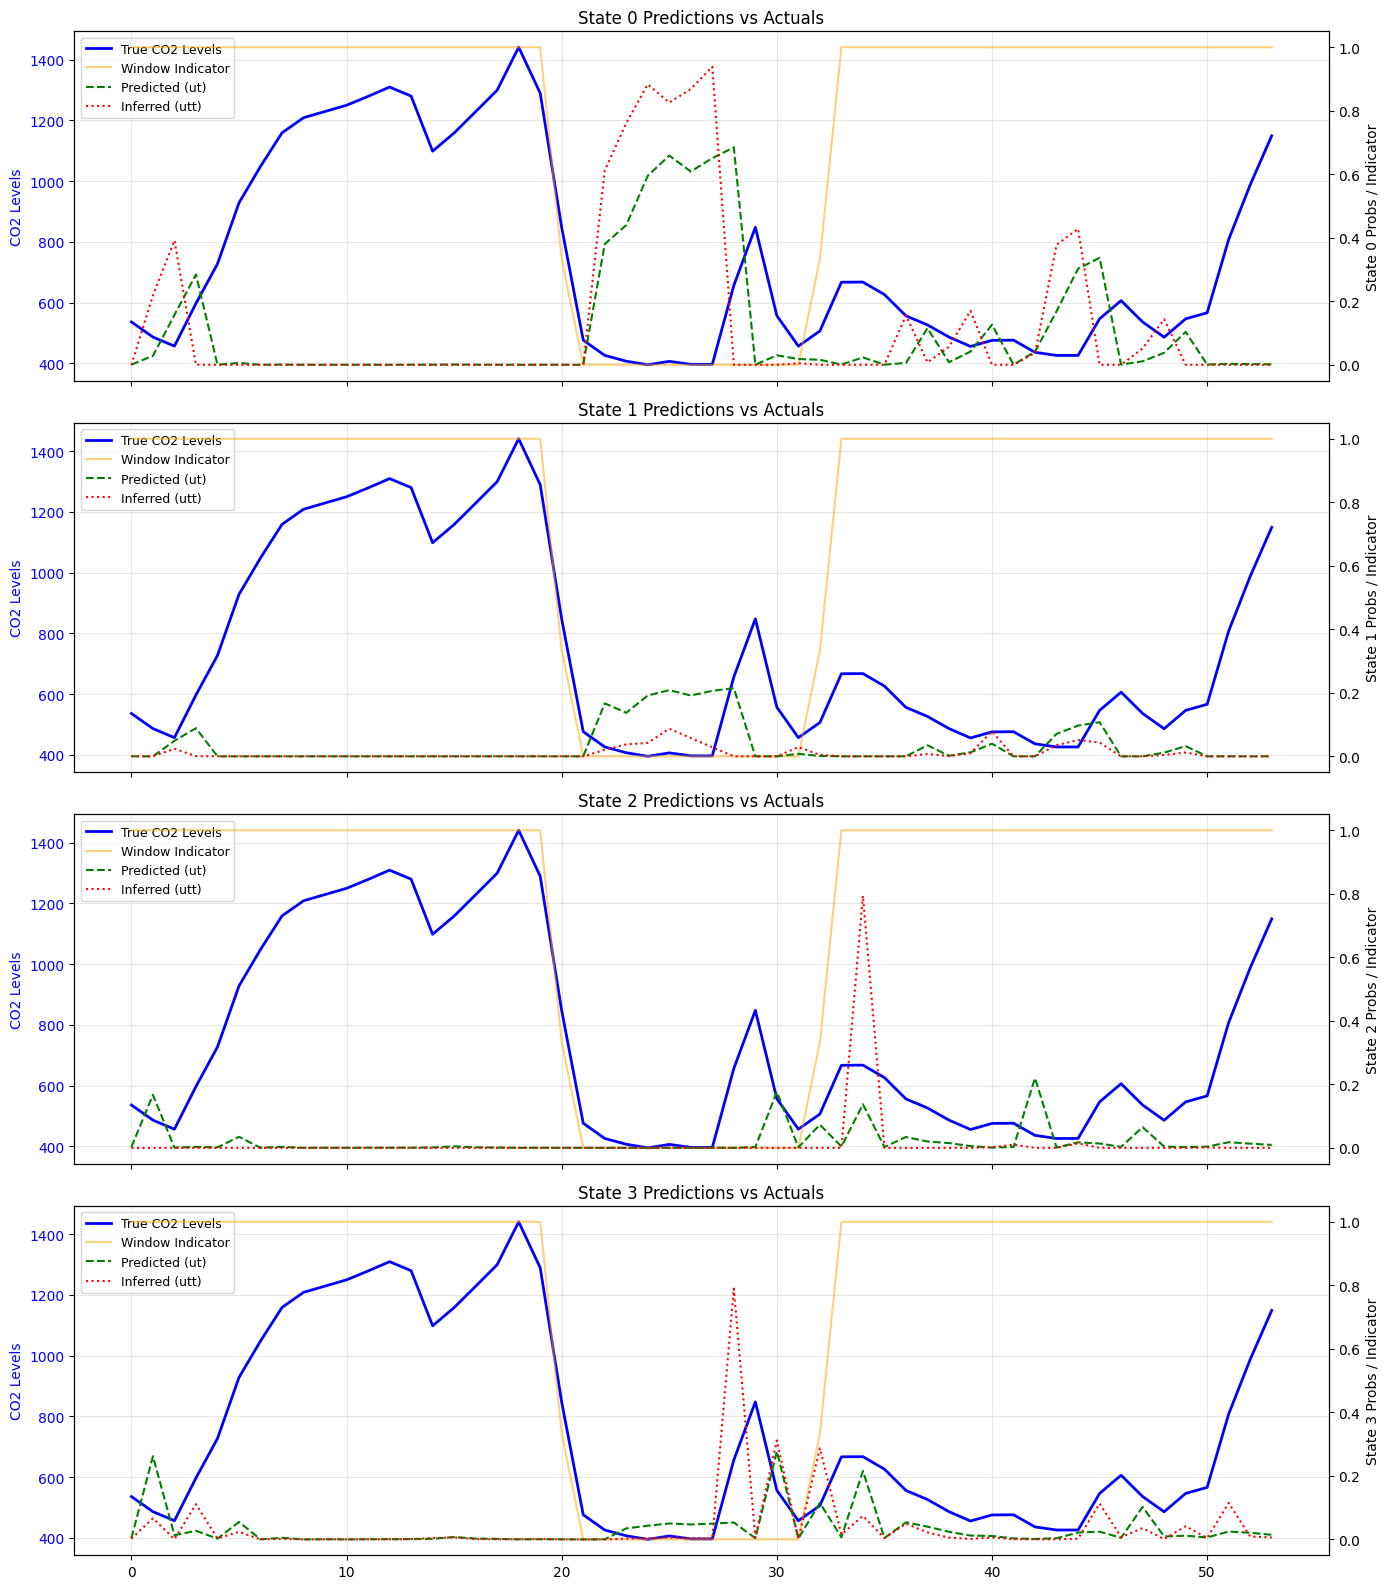

In [159]:
models = [
    "ordinary_hmm.pkl",
    "ar_hmm.pkl",
    "ar_2_hmm.pkl",
    "second_order_hmm.pkl",
    "covariate_hmm.pkl",
    "ar_1_covariate_hmm.pkl",
    "ar_2_covariate_hmm.pkl",
    "ar_2_second_order_hmm.pkl"
]

for model_name in models:
    model = load_model(BASE_MODEL_PATH + model_name)
    print("Model:", model_name)
    plot_predictions_all_states(model, ys, window_indicator, start_time=start_idx, timesteps=54)